In [1]:
import utils
import models
import dataset
import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2

In [10]:
X, Y = dataset.load_data(velocity = False, downsample=50, lag = 5)
X_train, Y_train, X_test, Y_test = dataset.partition_data(X, Y, split_ratio = [.8, .2])


In [3]:
kf = models.KalmanFilter()
kf.train_model(X_train, Y_train)
kf_yhat = kf.run_model(X_test, Y_test[0, :])


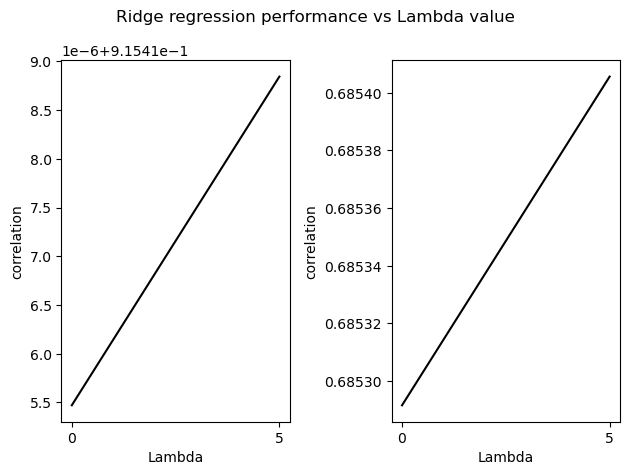

In [4]:
rr = models.RidgeRegression()
rr.train_model(X_train, Y_train)
rr_yhat = rr.run_model(X_test, Y_test[0, :])


In [5]:
nn = models.LSTM()
nn.train_model(X_train, Y_train)
nn_yhat = nn.run_model(X_test)

Epoch 1/10 | Train Loss: 0.9297 | Val Loss: 0.8423
Epoch 3/10 | Train Loss: 0.5169 | Val Loss: 0.5011
Epoch 5/10 | Train Loss: 0.4523 | Val Loss: 0.4469
Epoch 7/10 | Train Loss: 0.3951 | Val Loss: 0.3914
Epoch 9/10 | Train Loss: 0.3513 | Val Loss: 0.3575
Epoch 10/10 | Train Loss: 0.3413 | Val Loss: 0.3467


Epoch 1/10 | Train Loss: 0.6963 | Val Loss: 0.5248
Epoch 3/10 | Train Loss: 0.3999 | Val Loss: 0.3834
Epoch 5/10 | Train Loss: 0.3496 | Val Loss: 0.3525
Epoch 7/10 | Train Loss: 0.3314 | Val Loss: 0.3395
Epoch 9/10 | Train Loss: 0.3228 | Val Loss: 0.3281
Epoch 10/10 | Train Loss: 0.3187 | Val Loss: 0.3297


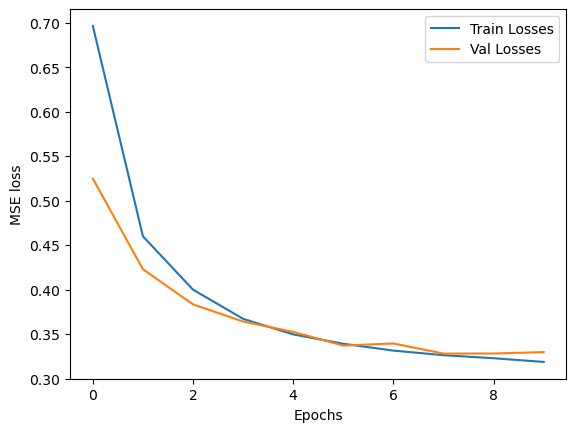

In [6]:
mlp = models.MLP()
mlp.train_model(X_train, Y_train)
mlp_yhat = mlp.run_model(X_test)


In [7]:
knet = models.KalmanNet()
knet.train_model(X_train, Y_train)
knet_yhat = knet.run_model(X_test, Y_test[0, :])


/home/riopar/anaconda3/envs/emg_decoding/lib/python3.13/site-packages/torch/nn/modules/loss.py:610: UserWarning: Using a target size (torch.Size([2])) that is different to the input size (torch.Size([64, 2])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/home/riopar/anaconda3/envs/emg_decoding/lib/python3.13/site-packages/torch/nn/modules/loss.py:610: UserWarning: Using a target size (torch.Size([2])) that is different to the input size (torch.Size([23, 2])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


Epoch 1/10, Loss: 35.2952
Epoch 2/10, Loss: 27.6985
Epoch 3/10, Loss: 25.4685
Epoch 4/10, Loss: 24.6950
Epoch 5/10, Loss: 24.5860
Epoch 6/10, Loss: 24.6680
Epoch 7/10, Loss: 23.5301
Epoch 8/10, Loss: 23.2910
Epoch 9/10, Loss: 22.8676
Epoch 10/10, Loss: 23.0198


In [8]:
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
end_plot = 500
start = 100

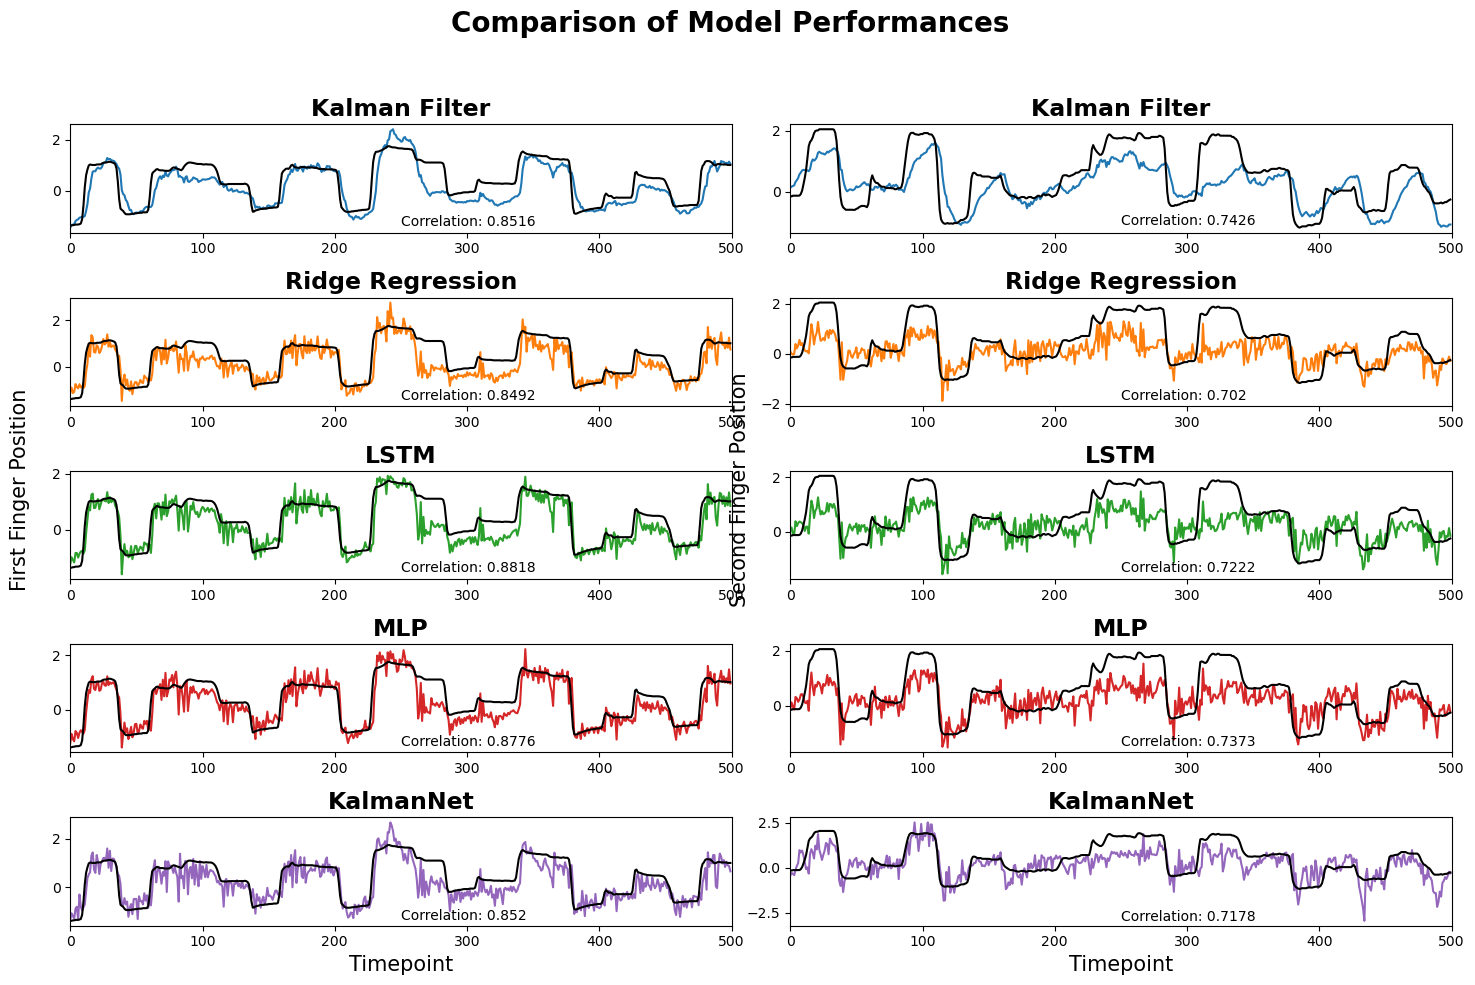

In [9]:
utils.compare_perfs(Y_test, [kf_yhat, rr_yhat, nn_yhat, mlp_yhat, knet_yhat], model_labels = ["Kalman Filter", "Ridge Regression", "LSTM", "MLP", "KalmanNet"], colors = colors, start = start, end = start + end_plot)